In [2]:
import numpy as np

attack='exp/scores/attack_8_clusters_1.3'

In [3]:
import os

scores = {}

for item in os.listdir(attack):
    item_path = os.path.join(attack, item)
    if os.path.isdir(item_path):
        
        print(item_path)

exp/scores/attack_8_clusters_1.3/mixkit-fast-double-click-on-mouse-275
exp/scores/attack_8_clusters_1.3/mixkit-modern-technology-select-3124
exp/scores/attack_8_clusters_1.3/calibration
exp/scores/attack_8_clusters_1.3/mixkit-classic-click-1117
exp/scores/attack_8_clusters_1.3/mixkit-camera-shutter-click-1133
exp/scores/attack_8_clusters_1.3/mixkit-mouse-click-close-1113
exp/scores/attack_8_clusters_1.3/mixkit-mouse-hard-clicking-1111
exp/scores/attack_8_clusters_1.3/clean
exp/scores/attack_8_clusters_1.3/mixkit-typewriter-soft-click-1125
exp/scores/attack_8_clusters_1.3/mixkit-hard-typewriter-click-1119


In [4]:
prior=0.5
t = -np.log(prior) + np.log(1-prior)

In [5]:
t

0.0

In [10]:
import pandas as p

scores = p.read_csv(attack + '/mixkit-hard-typewriter-click-1119/cosine/voxceleb1_scores_cal.csv')
trials = p.read_csv('data/voxceleb1_test/trials_short.csv')

merged_df = p.merge(trials, scores, on=['modelid', 'segmentid'], how='inner')

In [5]:
merged_df

,modelid,segmentid,targettype,LLR
0,id10001-1zcIwhmdeo4-00001,id10001-9mQ11vBs1wc-00003,target,4.054219
1,id10001-1zcIwhmdeo4-00001,id10001-J9lHsKG98U8-00021,target,3.090674
2,id10001-1zcIwhmdeo4-00001,id10001-J9lHsKG98U8-00024,target,5.267128
3,id10001-1zcIwhmdeo4-00001,id10001-zELwAz2W6hM-00009,target,3.904206
4,id10001-1zcIwhmdeo4-00001,id10104-MSV9xFqcEh8-00006,nontarget,-4.202379
...,...,...,...,...
99995,id10111-NtICHG3PV6A-00005,id10111-3FIiSPMPF1Y-00019,target,4.317848
99996,id10111-NtICHG3PV6A-00005,id10111-Mx9hN4LD_oI-00001,target,3.198005
99997,id10111-NtICHG3PV6A-00005,id10111-rUFh-NA1DH8-00008,target,3.944119
99998,id10111-NtICHG3PV6A-00005,id10111-vYeUCJ1iPYI-00006,target,4.213775


In [11]:
nb_non_tar = 0
imposter = 0
nb_tar = 0
false_rej = 0

for i, row in merged_df.iterrows():
    score = row['LLR']

    if row['targettype'] == 'nontarget':
        nb_non_tar = nb_non_tar + 1

        if float(score) > t:
            imposter = imposter + 1

    else:
        nb_tar = nb_tar + 1

        if float(score) < t:
            false_rej = false_rej + 1

In [13]:
false_rej

6370

In [12]:
imposter

3685

In [14]:
(imposter/nb_non_tar)*100

7.3326037210227835

In [15]:
(false_rej/nb_tar)*100

12.805307066036786

In [2]:
import pandas as p

scores = p.read_csv(attack + '/clean/cosine/voxceleb1_scores.csv')
trials = p.read_csv('data/voxceleb1_test/trials_no_duplicates.csv')

merged_df = p.merge(trials, scores, on=['modelid', 'segmentid'], how='inner')

In [13]:
merged_df

,modelid,segmentid,targettype,LLR
0,id10001-1zcIwhmdeo4-00001,id10001-9mQ11vBs1wc-00003,target,0.531370
1,id10001-1zcIwhmdeo4-00001,id10001-J9lHsKG98U8-00021,target,0.474504
2,id10001-1zcIwhmdeo4-00001,id10001-J9lHsKG98U8-00024,target,0.602954
3,id10001-1zcIwhmdeo4-00001,id10001-zELwAz2W6hM-00009,target,0.522517
4,id10001-1zcIwhmdeo4-00001,id10104-MSV9xFqcEh8-00006,nontarget,0.044083
...,...,...,...,...
1162947,id11251-s4R4hvqrhFw-00009,id10952-2VSL8E2aIsc-00003,nontarget,0.071658
1162948,id11251-s4R4hvqrhFw-00009,id11251-7GtZpUtReJ8-00001,target,0.524276
1162949,id11251-s4R4hvqrhFw-00009,id11251-7GtZpUtReJ8-00002,target,0.536357
1162950,id11251-s4R4hvqrhFw-00009,id11251-gFfcgOVmiO0-00007,target,0.412498


In [4]:
from sklearn import metrics

scores = merged_df['LLR'].tolist()
y = merged_df['targettype'].apply(lambda x: 1 if x == 'target' else 0).tolist()

fpr, tpr, thresholds = metrics.roc_curve(y, scores)

In [5]:
thresholds

array([        inf,  0.99995232,  0.9819718 , ..., -0.231757  ,
       -0.23177059, -0.40601927])

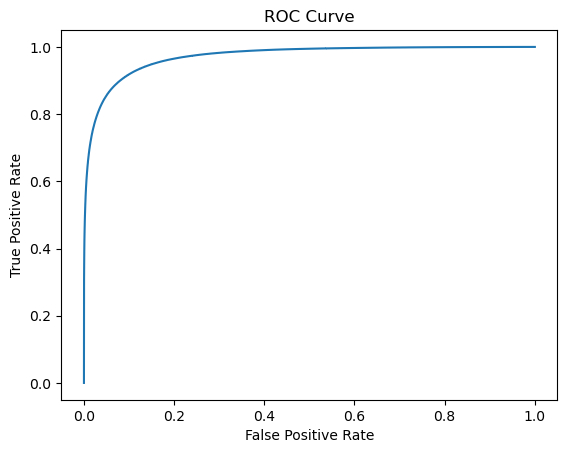

In [6]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [7]:
import numpy as np

j_scores = tpr - fpr
ix = np.argmax(j_scores)
best_threshold = thresholds[ix]

print('Best Threshold:', best_threshold)

Best Threshold: 0.3064867854118347


In [8]:
nb_non_tar = 0
imposter = 0
nb_tar = 0
false_rej = 0

for i, row in merged_df.iterrows():
    score = row['LLR']

    if row['targettype'] == 'nontarget':
        nb_non_tar = nb_non_tar + 1

        if float(score) > best_threshold:
            imposter = imposter + 1

    else:
        nb_tar = nb_tar + 1

        if float(score) < best_threshold:
            false_rej = false_rej + 1

In [9]:
false_rej

54045

In [10]:
imposter

50702

In [11]:
(false_rej/nb_tar)*100

9.336712482119534

In [13]:
(imposter/nb_non_tar)*100

8.680244064453833